In [544]:
import vbjax as vb
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import time
import sys
import os
import pandas as pd
import seaborn as sns
import tqdm
import jax.example_libraries.optimizers as jopt
from jax.scipy.special import kl_div
import networkx as nx
from copy import deepcopy
from scipy.stats import ks_2samp, entropy

In [545]:
cwd = os.getcwd()
functions_path = os.path.join(os.path.dirname(cwd), 'functions')
if functions_path not in sys.path:
    sys.path.append(functions_path)
import site
# Add user site-packages path manually
site_user_base = site.getusersitepackages()
if site_user_base not in sys.path:
    sys.path.append(site_user_base)
import mpr_jax
import FCD_jax
import utils
from importlib import reload
mpr_jax=reload(mpr_jax)
FCD_jax=reload(FCD_jax)

In [546]:
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform" 
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]="false"
os.environ["JAX_ENABLE_X64"] = "True"

In [547]:
%matplotlib inline

##  data

SC size whole SC

In [788]:
datapath = utils.DATA_ROOT
weights = np.loadtxt(os.path.join(datapath, "weights.txt"))
weights = weights#[:10,:10]
nn = len(weights)
SC = jnp.array(weights) / jnp.max(weights)

weights=SC
params = {"G": 0.33, 
          "weights": weights,
          "t_end": 3000, #t_end 300_000, cut 10_000, tr 500
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 5.0, # set to 500 to subsaple BOLD
          "seed":42
          }

wwidth = 30  # must be < 60
maxNwindows = 300
olap = 0.94
cut = 20 #number of initial time points discarded from the BOLD signal (if BOLD was subsampled, discard 20 only)
tr = 1

def timer(func):
    def wrapper(*args, **kwargs):
        import time
        start = time.time()
        result = func(*args, **kwargs)
        print(f"{func.__name__} took {time.time() - start:.2f} seconds")
        return result
    return wrapper

@timer
def wrapper(g, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par)
    data = sde.run({})
    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d
    
rv_t, r, v, bold_t, bold_d =  wrapper(0.00, params)

wrapper took 1.25 seconds


In [789]:
np.shape(bold_d.T) #simulate the full BOLD

(88, 600)

In [790]:
FC = np.corrcoef(bold_d[cut:].T)

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d[cut::tr].T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]
#u_FCD = FCD[jnp.triu_indices_from(FCD, k=1)]

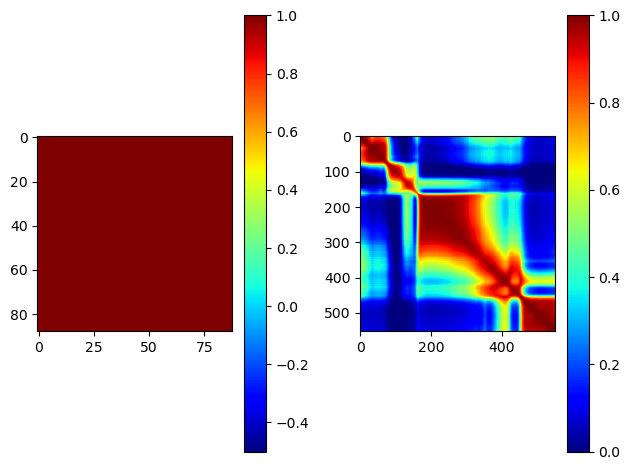

In [791]:
fig, ax = plt.subplots(ncols=2)
im1 = ax[0].imshow(FC, vmin=-0.5, vmax=1, cmap='jet') 
im = ax[1].imshow(FCD, vmin=0, vmax=1, cmap='jet') 
fig.colorbar(im1) 
fig.colorbar(im)
plt.tight_layout()

In [792]:
np.shape(FC)

(88, 88)

In [793]:
np.shape(FCD)

(551, 551)

In [794]:
np.shape(u_FC)

(3828,)

In [795]:
np.shape(zu_FC)

(3828,)

In [796]:
np.shape(u_FCD)

(135981,)

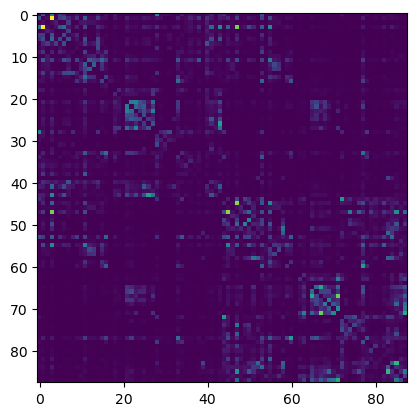

In [797]:
plt.imshow(SC)

## simulator

In [798]:
@timer
def wrapper_with_key(g, key, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    #par["seed"] = seed
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par,key)
    data = sde.run({})
    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d

In [799]:
def run_for_prms_mod(G,key) :
    
    #KEY = jax.random.PRNGKey(0)
    #_, key = jax.random.split(KEY) 
    #bold = run(p, key)
    #seed = int(time.time())

    rv_t, r, v, bold_t, bold_d = wrapper_with_key(G, key, params)
    
    print(G,len(bold_d))
    #sim_fcd = get_fcd(bold_ds)
    sim_fc = jnp.corrcoef(bold_d[cut:].T)
    sim_fcd, FCvec,_ = FCD_jax.extract_FCD(bold_d[cut::tr].T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
    
    return bold_d, sim_fc, sim_fcd

In [800]:
def try_loss_mod(prm, key):
    
    losses = {}
    sim_bold, sim_fc, sim_fcd = run_for_prms_mod(prm, key)
    
    losses['mean_fc'] = (jnp.mean(FC) - jnp.mean(jnp.nan_to_num(sim_fc, nan=0.)))**2
    
    u_sim_fc = sim_fc[jnp.triu_indices_from(sim_fc, k=1)]
    zu_sim_fc = (u_sim_fc - jnp.mean(u_sim_fc)) / jnp.std(u_sim_fc)
    r = jnp.corrcoef(zu_sim_fc.flatten(), zu_FC.flatten())[0, 1]
    losses['corr_fc'] = jnp.nan_to_num(r, nan=0.)
    
    u_sim_fcd = sim_fcd[jnp.triu_indices_from(sim_fcd, k=30)]
    losses['var_fcd'] = (jnp.var(u_FCD) - jnp.nan_to_num(jnp.var(u_sim_fcd), nan=0.))**2
    #u_FCD_cut = u_FCD[jnp.triu_indices_from(u_FCD, k=30)]
    #u_sim_fcd = sim_fcd[jnp.triu_indices_from(sim_fcd, k=30)]
    #losses['var_fcd'] = (jnp.var(u_FCD_cut) - jnp.var(u_sim_fcd))**2
    print(np.shape(u_sim_fcd),np.shape(u_FCD))
    kl = kl_div(u_sim_fcd.flatten(), jnp.nan_to_num(u_FCD.flatten(), nan=0.))
    losses['kl_fcd'] = jnp.nan_to_num(jnp.mean(kl), nan=1e6)
    
    losses['mse_fc'] = np.mean((FC - jnp.nan_to_num(sim_fc, nan=0.))**2)
    
    return losses

In [801]:
g_values = np.arange(0., 1.5, 0.05)
loss_sweep_mod = {'mean_fc':[], 'corr_fc':[], 'var_fcd':[], 'kl_fcd':[], 'mse_fc': []}
for g in g_values :
    key = jax.random.PRNGKey(int(time.time()))
    loss = try_loss_mod(g, key)
    for dictkey in loss_sweep_mod.keys() :
        loss_sweep_mod[dictkey].append(loss[dictkey])

wrapper_with_key took 1.34 seconds
0.0 600
(135981,) (135981,)
wrapper_with_key took 0.84 seconds
0.05 600
(135981,) (135981,)
wrapper_with_key took 0.76 seconds
0.1 600
(135981,) (135981,)
wrapper_with_key took 0.98 seconds
0.15000000000000002 600
(135981,) (135981,)
wrapper_with_key took 0.81 seconds
0.2 600
(135981,) (135981,)
wrapper_with_key took 0.76 seconds
0.25 600
(135981,) (135981,)
wrapper_with_key took 0.81 seconds
0.30000000000000004 600
(135981,) (135981,)
wrapper_with_key took 0.86 seconds
0.35000000000000003 600
(135981,) (135981,)
wrapper_with_key took 0.96 seconds
0.4 600
(135981,) (135981,)
wrapper_with_key took 0.97 seconds
0.45 600
(135981,) (135981,)
wrapper_with_key took 0.95 seconds
0.5 600
(135981,) (135981,)
wrapper_with_key took 0.77 seconds
0.55 600
(135981,) (135981,)
wrapper_with_key took 0.89 seconds
0.6000000000000001 600
(135981,) (135981,)
wrapper_with_key took 0.89 seconds
0.65 600
(135981,) (135981,)
wrapper_with_key took 0.90 seconds
0.7000000000000

In [802]:
for key in loss_sweep_mod.keys() :
    loss_sweep_mod[key] = np.array(loss_sweep_mod[key])

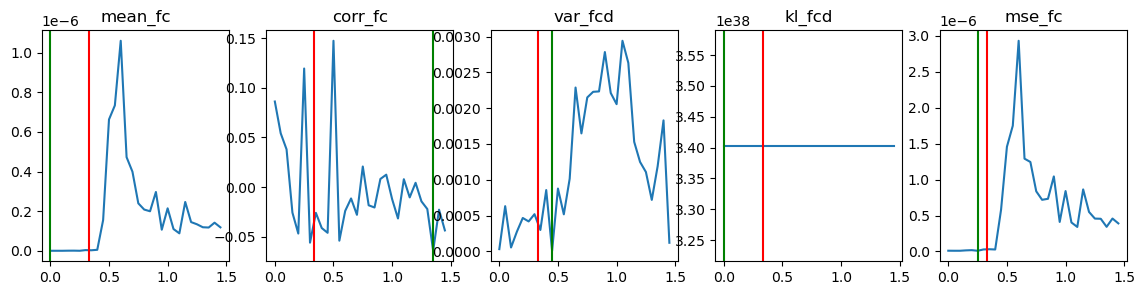

In [803]:
fig, ax = plt.subplots(ncols=len(loss_sweep_mod), figsize=(14, 3))
for i, (k,v) in enumerate(loss_sweep_mod.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.33, color='r')
    min_index = np.argmin(v)
    ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

## add KL and KS losses for both FC and FCD

In [804]:
def try_loss_mod_extended(prm, FC_obs, FCD_obs, FC_obs_flat, FCD_obs_flat, key, wwidth=30, olap=0.94, bins=50):
    """
    Compute multiple loss components between simulated and observed FC/FCD.
    """

    losses = {}
    sim_bold, sim_fc, sim_fcd = run_for_prms_mod(prm, key)

    # --- 1. Static FC measures ---
    sim_fc_np = np.array(sim_fc)
    obs_fc_np = np.array(FC_obs)
    
    # mean FC difference
    losses["mean_fc"] = float((np.mean(obs_fc_np) - np.mean(sim_fc_np)) ** 2)
    
    # upper triangle indices
    
    u_sim_fc = sim_fc[jnp.triu_indices_from(sim_fc, k=1)]
    zu_sim_fc = (u_sim_fc - jnp.mean(u_sim_fc)) / jnp.std(u_sim_fc)
    r = jnp.corrcoef(zu_sim_fc.flatten(), zu_FC.flatten())[0, 1]
    
    iu = np.triu_indices_from(sim_fc_np, k=1)
    u_sim_fc = sim_fc_np[iu]
    u_obs_fc = obs_fc_np[iu]
    
    # correlation of FC patterns
    zu_sim_fc = (u_sim_fc - np.mean(u_sim_fc)) / (np.std(u_sim_fc) + 1e-8)
    zu_obs_fc = (u_obs_fc - np.mean(u_obs_fc)) / (np.std(u_obs_fc) + 1e-8)
    r = np.corrcoef(zu_sim_fc, zu_obs_fc)[0, 1]
    losses["corr_fc"] = float(np.nan_to_num(r, nan=0.0))
    
    # MSE of FC
    losses["mse_fc"] = float(np.mean((obs_fc_np - sim_fc_np) ** 2))

    # --- 2. FC distributional measures ---
    sim_fc_flat = np.array(sim_fc_np).ravel()
    obs_fc_flat = np.array(FC_obs_flat)

    # KS distance
    losses["ks_fc"] = float(ks_2samp(obs_fc_flat, sim_fc_flat)[0])

    # histogram-based KL divergence
    eps = 1e-8
    p_hist, edges = np.histogram(obs_fc_flat, bins=bins, density=True)
    q_hist, _ = np.histogram(sim_fc_flat, bins=edges, density=True)
    p = (p_hist + eps) / (p_hist + eps).sum()
    q = (q_hist + eps) / (q_hist + eps).sum()
    losses["kl_fc_hist"] = float(entropy(p, q))

    # --- 3. Dynamic FCD measures ---
    sim_fcd_np = np.array(sim_fcd)
    obs_fcd_np = np.array(FCD_obs)

    # same diagonal skip for both
    iu_fcd = np.triu_indices_from(sim_fcd_np, k=30)
    u_sim_fcd = sim_fcd_np[iu_fcd]
    u_obs_fcd = obs_fcd_np[iu_fcd]

    # variance difference
    losses["var_fcd"] = float((np.var(u_obs_fcd) - np.var(u_sim_fcd)) ** 2)

    # KS for FCD
    #losses["ks_fcd"] = float(ks_2samp(FCD_obs_flat, np.ravel(sim_fcd_np))[0])

    # histogram-based KL for FCD
    #p_hist, edges = np.histogram(FCD_obs_flat, bins=bins, density=True)
    #q_hist, _ = np.histogram(np.ravel(sim_fcd_np), bins=edges, density=True)


    losses["ks_fcd"] = float(ks_2samp(u_obs_fcd, u_sim_fcd)[0])
    
    # Histogram-based KL for FCD (only on selected upper triangle values)
    eps = 1e-8
    p_hist, edges = np.histogram(u_obs_fcd, bins=bins, density=True)
    q_hist, _ = np.histogram(u_sim_fcd, bins=edges, density=True)

    

    p = (p_hist + eps) / (p_hist + eps).sum()
    q = (q_hist + eps) / (q_hist + eps).sum()
    losses["kl_fcd_hist"] = float(entropy(p, q))

    return losses


In [805]:
g_values = np.arange(0., 1.5, 0.05)
loss_sweep_mod_extended = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    key = jax.random.PRNGKey(int(time.time()))
    loss = try_loss_mod_extended(g, FC, FCD, u_FC, u_FCD, key)
    for key in loss_sweep_mod_extended.keys() :
        loss_sweep_mod_extended[key].append(loss[key])

wrapper_with_key took 0.83 seconds
0.0 600
wrapper_with_key took 0.88 seconds
0.05 600
wrapper_with_key took 0.76 seconds
0.1 600
wrapper_with_key took 0.71 seconds
0.15000000000000002 600
wrapper_with_key took 0.80 seconds
0.2 600
wrapper_with_key took 0.77 seconds
0.25 600
wrapper_with_key took 0.72 seconds
0.30000000000000004 600
wrapper_with_key took 0.88 seconds
0.35000000000000003 600
wrapper_with_key took 0.81 seconds
0.4 600
wrapper_with_key took 0.69 seconds
0.45 600
wrapper_with_key took 0.58 seconds
0.5 600
wrapper_with_key took 0.86 seconds
0.55 600
wrapper_with_key took 0.68 seconds
0.6000000000000001 600
wrapper_with_key took 0.96 seconds
0.65 600
wrapper_with_key took 0.87 seconds
0.7000000000000001 600
wrapper_with_key took 0.93 seconds
0.75 600
wrapper_with_key took 0.83 seconds
0.8 600
wrapper_with_key took 0.74 seconds
0.8500000000000001 600
wrapper_with_key took 0.82 seconds
0.9 600
wrapper_with_key took 0.90 seconds
0.9500000000000001 600
wrapper_with_key took 0.97

In [806]:
for key in loss_sweep_mod_extended.keys() :
    loss_sweep_mod_extended[key] = np.array(loss_sweep_mod_extended[key])

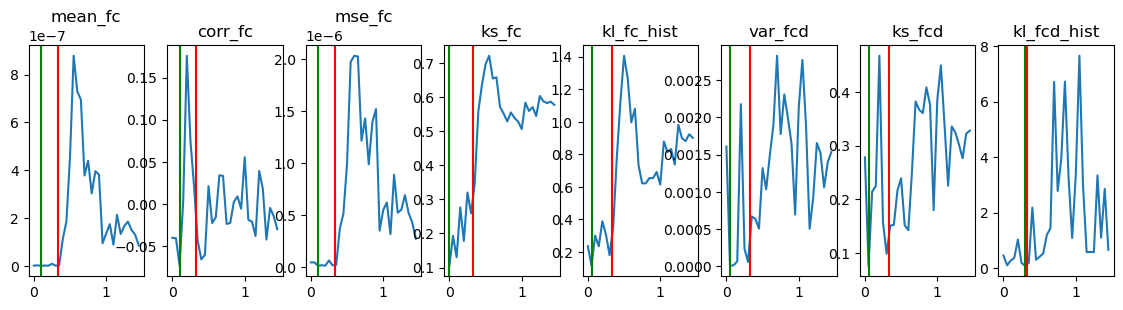

In [807]:
fig, ax = plt.subplots(ncols=len(loss_sweep_mod_extended), figsize=(14, 3))
for i, (k,v) in enumerate(loss_sweep_mod_extended.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.33, color='r')
    min_index = np.argmin(v)
    ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

kl_fc is not working for the 6x6 case because FC is also 6x6 (36 elements) and an histogram of 50 bins is almost empty so i get a lot of NaNs

it will be better with bigger SC matrix (alternative for the 6x6 case is to not making the histogram but FC_flat is not a distribution itself so i is not okay)

## take average on multiple simulations in order to smooth loss

In [808]:
import jax
import jax.numpy as jnp
import numpy as np
from scipy.stats import ks_2samp, entropy
import time

def try_loss_mod_per_key(prm, FC_obs, FCD_obs, FC_obs_flat, FCD_obs_flat, 
                         n_keys=10, wwidth=30, olap=0.94, bins=50):
    """
    Compute multiple loss components between simulated and observed FC/FCD,
    evaluating each random seed separately and then aggregating losses.
    """

    base_key = jax.random.PRNGKey(int(time.time()))
    #base_key = jax.random.PRNGKey(0)
    keys = jax.random.split(base_key, n_keys)

    def run_with_key(key):
        sim_bold, sim_fc, sim_fcd = run_for_prms_mod(prm, key)
        return sim_fc, sim_fcd

    # Vectorized run for all keys
    fcs, fcds = jax.vmap(run_with_key)(keys)

    # Convert to numpy for analysis
    fcs_np = np.array(fcs)
    fcds_np = np.array(fcds)

    obs_fc_np = np.array(FC_obs)
    obs_fc_flat_np = np.array(FC_obs_flat)
    obs_fcd_np = np.array(FCD_obs)
    obs_fcd_flat_np = np.array(FCD_obs_flat)

    losses = {
        "mean_fc": 0.0,
        "corr_fc": 0.0,
        "mse_fc": 0.0,
        "ks_fc": 0.0,
        "kl_fc_hist": 0.0,
        "var_fcd": 0.0,
        "ks_fcd": 0.0,
        "kl_fcd_hist": 0.0,
    }

    eps = 1e-8

    # Compute losses separately for each simulation, then sum
    for sim_fc, sim_fcd in zip(fcs_np, fcds_np):
        # --- FC losses ---
        losses["mean_fc"] += (np.mean(obs_fc_np) - np.mean(sim_fc)) ** 2

        iu = np.triu_indices_from(sim_fc, k=1)
        u_sim_fc = sim_fc[iu]
        u_obs_fc = obs_fc_np[iu]
        zu_sim_fc = (u_sim_fc - np.mean(u_sim_fc)) / (np.std(u_sim_fc) + eps)
        zu_obs_fc = (u_obs_fc - np.mean(u_obs_fc)) / (np.std(u_obs_fc) + eps)
        r = np.corrcoef(zu_sim_fc, zu_obs_fc)[0, 1]
        losses["corr_fc"] += np.nan_to_num(r, nan=0.0)

        losses["mse_fc"] += np.mean((obs_fc_np - sim_fc) ** 2)

        # --- FC distributional metrics ---
        sim_fc_flat = sim_fc.flatten()
        losses["ks_fc"] += ks_2samp(obs_fc_flat_np, sim_fc_flat)[0]

        p_hist, edges = np.histogram(obs_fc_flat_np, bins=bins, density=True)
        q_hist, _ = np.histogram(sim_fc_flat, bins=edges, density=True)
        p = (p_hist + eps) / (p_hist + eps).sum()
        q = (q_hist + eps) / (q_hist + eps).sum()
        losses["kl_fc_hist"] += entropy(p, q)

        # --- FCD losses ---
        iu_fcd = np.triu_indices_from(sim_fcd, k=30)
        u_sim_fcd = sim_fcd[iu_fcd]
        u_obs_fcd = obs_fcd_np[iu_fcd]

        losses["var_fcd"] += (np.var(u_obs_fcd) - np.var(u_sim_fcd)) ** 2
        losses["ks_fcd"] += ks_2samp(u_obs_fcd, u_sim_fcd)[0]

        p_hist, edges = np.histogram(u_obs_fcd, bins=bins, density=True)
        q_hist, _ = np.histogram(u_sim_fcd, bins=edges, density=True)
        p = (p_hist + eps) / (p_hist + eps).sum()
        q = (q_hist + eps) / (q_hist + eps).sum()
        losses["kl_fcd_hist"] += entropy(p, q)

        #print((np.mean(obs_fc_np) - np.mean(sim_fc)) ** 2, np.corrcoef(zu_sim_fc, zu_obs_fc)[0, 1], np.mean((obs_fc_np - sim_fc) ** 2))
    # Average or keep sum 
    #for k in losses:
    #    losses[k] = float(losses[k] / n_keys)  

    return losses


In [809]:
g_values = np.arange(0., 1.5, 0.05)
losses = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss = try_loss_mod_per_key(g, FC, FCD, u_FC, u_FCD)
    for key in losses.keys() :
        losses[key].append(loss[key])

wrapper_with_key took 4.33 seconds
0.0 600
wrapper_with_key took 3.76 seconds
0.05 600
wrapper_with_key took 3.84 seconds
0.1 600
wrapper_with_key took 3.70 seconds
0.15000000000000002 600
wrapper_with_key took 3.69 seconds
0.2 600
wrapper_with_key took 3.94 seconds
0.25 600
wrapper_with_key took 3.88 seconds
0.30000000000000004 600
wrapper_with_key took 3.78 seconds
0.35000000000000003 600
wrapper_with_key took 3.77 seconds
0.4 600
wrapper_with_key took 3.98 seconds
0.45 600
wrapper_with_key took 3.56 seconds
0.5 600
wrapper_with_key took 3.77 seconds
0.55 600
wrapper_with_key took 3.71 seconds
0.6000000000000001 600
wrapper_with_key took 3.69 seconds
0.65 600
wrapper_with_key took 3.44 seconds
0.7000000000000001 600
wrapper_with_key took 3.74 seconds
0.75 600
wrapper_with_key took 3.49 seconds
0.8 600
wrapper_with_key took 3.48 seconds
0.8500000000000001 600
wrapper_with_key took 3.74 seconds
0.9 600
wrapper_with_key took 3.71 seconds
0.9500000000000001 600
wrapper_with_key took 3.71

In [810]:
for key in losses.keys() :
    losses[key] = np.array(losses[key])

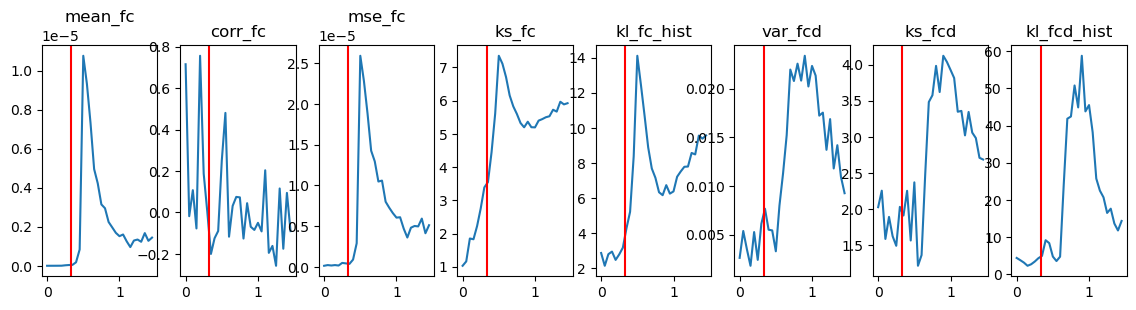

In [811]:
fig, ax = plt.subplots(ncols=len(losses), figsize=(14, 3))
for i, (k,v) in enumerate(losses.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.33, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

## infer different values of g

In [812]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.0, params)

wrapper took 1.01 seconds


In [813]:
FC = np.corrcoef(bold_d[cut:].T)

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d[cut::tr].T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]
#u_FCD = FCD[jnp.triu_indices_from(FCD, k=1)]

In [814]:
g_values = np.arange(0., 1.5, 0.05)
losses0 = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss0 = try_loss_mod_per_key(g, FC, FCD, u_FC, u_FCD)
    for key in losses0.keys() :
        losses0[key].append(loss0[key])

wrapper_with_key took 3.87 seconds
0.0 600
wrapper_with_key took 3.70 seconds
0.05 600
wrapper_with_key took 3.96 seconds
0.1 600
wrapper_with_key took 4.00 seconds
0.15000000000000002 600
wrapper_with_key took 3.68 seconds
0.2 600
wrapper_with_key took 3.56 seconds
0.25 600
wrapper_with_key took 3.50 seconds
0.30000000000000004 600
wrapper_with_key took 4.44 seconds
0.35000000000000003 600
wrapper_with_key took 3.82 seconds
0.4 600
wrapper_with_key took 3.72 seconds
0.45 600
wrapper_with_key took 3.95 seconds
0.5 600
wrapper_with_key took 4.42 seconds
0.55 600
wrapper_with_key took 4.41 seconds
0.6000000000000001 600
wrapper_with_key took 3.87 seconds
0.65 600
wrapper_with_key took 3.81 seconds
0.7000000000000001 600
wrapper_with_key took 3.91 seconds
0.75 600
wrapper_with_key took 3.77 seconds
0.8 600
wrapper_with_key took 3.43 seconds
0.8500000000000001 600
wrapper_with_key took 3.36 seconds
0.9 600
wrapper_with_key took 3.61 seconds
0.9500000000000001 600
wrapper_with_key took 3.38

In [815]:
for key in losses0.keys() :
    losses0[key] = np.array(losses0[key])

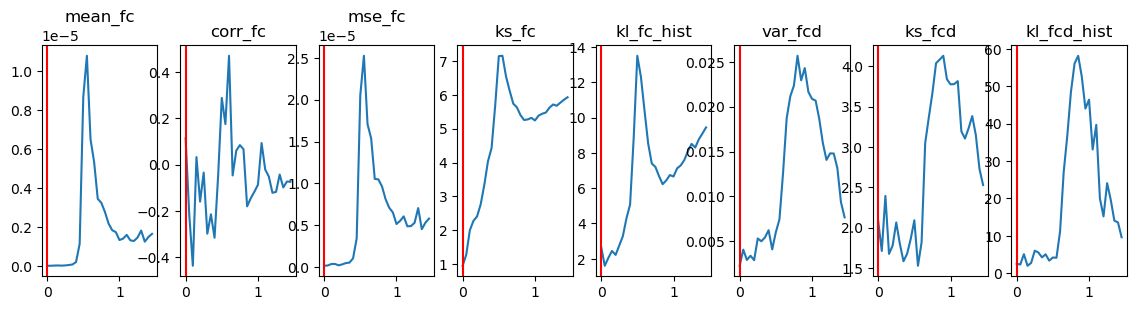

In [830]:
fig, ax = plt.subplots(ncols=len(losses0), figsize=(14, 3))
for i, (k,v) in enumerate(losses0.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.0, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

In [818]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.5, params)

wrapper took 0.72 seconds


In [819]:
FC = np.corrcoef(bold_d[cut:].T)

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d[cut::tr].T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]
#u_FCD = FCD[jnp.triu_indices_from(FCD, k=1)]

In [820]:
g_values = np.arange(0., 1.5, 0.05)
losses05 = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss05 = try_loss_mod_per_key(g, FC, FCD, u_FC, u_FCD)
    for key in losses05.keys() :
        losses05[key].append(loss05[key])

wrapper_with_key took 3.32 seconds
0.0 600
wrapper_with_key took 3.45 seconds
0.05 600
wrapper_with_key took 3.48 seconds
0.1 600
wrapper_with_key took 3.63 seconds
0.15000000000000002 600
wrapper_with_key took 3.49 seconds
0.2 600
wrapper_with_key took 3.49 seconds
0.25 600
wrapper_with_key took 3.38 seconds
0.30000000000000004 600
wrapper_with_key took 3.53 seconds
0.35000000000000003 600
wrapper_with_key took 3.54 seconds
0.4 600
wrapper_with_key took 3.57 seconds
0.45 600
wrapper_with_key took 3.40 seconds
0.5 600
wrapper_with_key took 3.27 seconds
0.55 600
wrapper_with_key took 3.45 seconds
0.6000000000000001 600
wrapper_with_key took 3.19 seconds
0.65 600
wrapper_with_key took 3.52 seconds
0.7000000000000001 600
wrapper_with_key took 3.57 seconds
0.75 600
wrapper_with_key took 3.68 seconds
0.8 600
wrapper_with_key took 3.31 seconds
0.8500000000000001 600
wrapper_with_key took 3.52 seconds
0.9 600
wrapper_with_key took 3.30 seconds
0.9500000000000001 600
wrapper_with_key took 3.49

In [821]:
for key in losses05.keys() :
    losses05[key] = np.array(losses05[key])

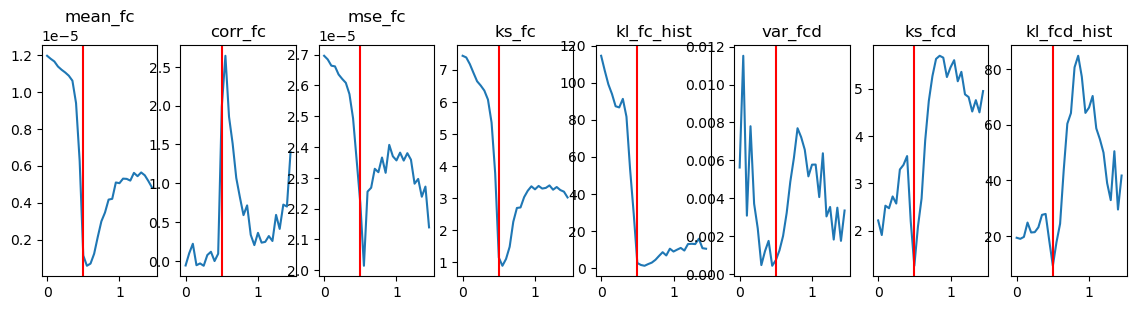

In [829]:
fig, ax = plt.subplots(ncols=len(losses05), figsize=(14, 3))
for i, (k,v) in enumerate(losses05.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.5, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

In [823]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.7, params)

wrapper took 0.88 seconds


In [824]:
FC = np.corrcoef(bold_d[cut:].T)

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d[cut::tr].T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]
#u_FCD = FCD[jnp.triu_indices_from(FCD, k=1)]

In [825]:
g_values = np.arange(0., 1.5, 0.05)
losses07 = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss07 = try_loss_mod_per_key(g, FC, FCD, u_FC, u_FCD)
    for key in losses07.keys() :
        losses07[key].append(loss07[key])

wrapper_with_key took 3.70 seconds
0.0 600
wrapper_with_key took 3.53 seconds
0.05 600
wrapper_with_key took 3.38 seconds
0.1 600
wrapper_with_key took 3.50 seconds
0.15000000000000002 600
wrapper_with_key took 3.56 seconds
0.2 600
wrapper_with_key took 3.33 seconds
0.25 600
wrapper_with_key took 3.64 seconds
0.30000000000000004 600
wrapper_with_key took 3.70 seconds
0.35000000000000003 600
wrapper_with_key took 3.72 seconds
0.4 600
wrapper_with_key took 3.48 seconds
0.45 600
wrapper_with_key took 3.74 seconds
0.5 600
wrapper_with_key took 3.65 seconds
0.55 600
wrapper_with_key took 3.81 seconds
0.6000000000000001 600
wrapper_with_key took 3.41 seconds
0.65 600
wrapper_with_key took 3.65 seconds
0.7000000000000001 600
wrapper_with_key took 3.51 seconds
0.75 600
wrapper_with_key took 3.41 seconds
0.8 600
wrapper_with_key took 3.67 seconds
0.8500000000000001 600
wrapper_with_key took 3.44 seconds
0.9 600
wrapper_with_key took 3.55 seconds
0.9500000000000001 600
wrapper_with_key took 3.44

In [826]:
for key in losses07.keys() :
    losses07[key] = np.array(losses07[key])

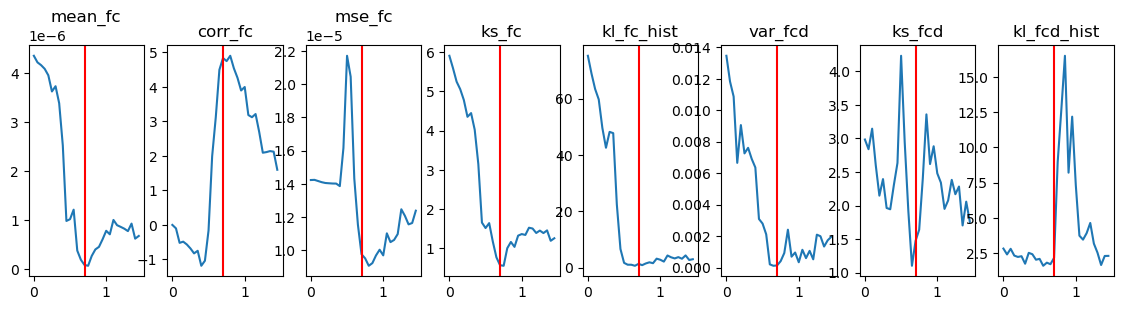

In [828]:
fig, ax = plt.subplots(ncols=len(losses07), figsize=(14, 3))
for i, (k,v) in enumerate(losses07.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.7, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)